In [ ]:
import os
from google.colab import drive

os.environ["KAGGLE_USERNAME"] = "your-kaggle-username"
os.environ["KAGGLE_KEY"] = "your-kaggle-api-key"

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

SEED         = 42
NUM_CLASSES  = 3
CLASS_NAMES  = ["COVID", "Normal", "Viral Pneumonia"]

IMG_SIZE     = 224
BATCH_SIZE   = 32
LR           = 1e-4
MAX_EPOCHS   = 30
PATIENCE     = 5
REDUCTION_SE = 16
VARIANTS     = ["baseline", "se", "spatial", "eca"]
NUM_GRADCAM  = 3

KAGGLE_SLUG  = "tawsifurrahman/covid19-radiography-database"
OUTPUT_DIR   = Path("/content/drive/MyDrive/cxr_outputs")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


In [ ]:
!pip install -q kagglehub scikit-learn seaborn

import math, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

import kagglehub


In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

DIRS = {
    "split":       OUTPUT_DIR / "split",
    "checkpoints": OUTPUT_DIR / "checkpoints",
    "logs":        OUTPUT_DIR / "logs",
    "metrics":     OUTPUT_DIR / "metrics",
    "figures":     OUTPUT_DIR / "figures",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)


Device: cuda | AMP: True


In [ ]:
def download_dataset():
    print("Downloading COVID-19 Radiography Database from Kaggle ...")
    path = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    print(f"Downloaded to: {path}")
    for candidate in [path] + [p for p in path.rglob("*") if p.is_dir()]:
        if all((candidate / cls).is_dir() for cls in CLASS_NAMES):
            return candidate
    raise RuntimeError(f"Could not locate class folders {CLASS_NAMES} under {path}")

def build_file_list(data_root):
    rows = []
    for label, cls in enumerate(CLASS_NAMES):
        cdir = Path(data_root) / cls
        img_dir = cdir / "images" if (cdir / "images").is_dir() else cdir
        files = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in (".png", ".jpg", ".jpeg"))
        for f in files:
            rows.append({"path": str(f), "label": label, "class_name": cls})
    df = pd.DataFrame(rows)
    print("Class counts:")
    print(df["class_name"].value_counts().to_string())
    return df

def make_splits(df):
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
        part.to_csv(DIRS["split"] / f"{name}.csv", index=False)
    print(f"Split -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")
    return (train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True))

data_root = download_dataset()
df = build_file_list(data_root)
train_df, val_df, test_df = make_splits(df)


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Downloaded to: /kaggle/input/covid19-radiography-database
Class counts:
class_name
Normal             10192
COVID               3616
Viral Pneumonia     1345
Split -> train 10607 | val 2273 | test 2273


In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CXRDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.tf(img), int(row["label"]), row["path"]

def make_loaders(train_df, val_df, test_df):
    pin = DEVICE == "cuda"
    train_loader = DataLoader(CXRDataset(train_df, train_tf), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=pin)
    val_loader   = DataLoader(CXRDataset(val_df, eval_tf), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=pin)
    test_loader  = DataLoader(CXRDataset(test_df, eval_tf), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=pin)
    return train_loader, val_loader, test_loader

def compute_class_weights(train_df):
    counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
    weights = counts.sum() / (NUM_CLASSES * counts)
    return torch.tensor(weights, dtype=torch.float32)

train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
class_weights = compute_class_weights(train_df)
print("Class weights:", class_weights.tolist())


Class weights: [1.396944522857666, 0.4956078827381134, 3.753361701965332]


In [ ]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu, Shen and Sun, 2018)."""
    def __init__(self, channels, reduction=REDUCTION_SE):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, channels), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s

class SpatialAttention(nn.Module):
    """Spatial attention branch (Woo et al., 2018): pool over channels, then a 7x7 convolution."""
    def __init__(self, channels=None, kernel=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel, padding=kernel // 2, bias=False)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        a = self.sig(self.conv(torch.cat([avg, mx], dim=1)))
        return x * a

class ECABlock(nn.Module):
    """Efficient Channel Attention (Wang et al., 2020): 1D convolution with an adaptive kernel size."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k // 2, bias=False)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, 1, c)
        y = self.sig(self.conv(y)).view(b, c, 1, 1)
        return x * y

ATTN = {"se": SEBlock, "spatial": SpatialAttention, "eca": ECABlock}

def build_model(variant):
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if variant != "baseline":
        make = ATTN[variant]
        m.layer1 = nn.Sequential(m.layer1, make(64))
        m.layer2 = nn.Sequential(m.layer2, make(128))
        m.layer3 = nn.Sequential(m.layer3, make(256))
        m.layer4 = nn.Sequential(m.layer4, make(512))
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def get_target_layer(model, variant):
    return model.layer4[-1] if variant == "baseline" else model.layer4[0][-1]

def count_params(model):
    return sum(p.numel() for p in model.parameters())

for v in VARIANTS:
    print(f"{v:>10s}: {count_params(build_model(v)):,} params")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 243MB/s]


  baseline: 11,178,051 params
        se: 11,222,591 params
   spatial: 11,178,443 params
       eca: 11,178,069 params


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_true, all_pred = 0.0, [], []
    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train):
            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                out = model(x)
                loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                if USE_AMP:
                    scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
                else:
                    loss.backward(); optimizer.step()
        total_loss += loss.item() * x.size(0)
        all_true.extend(y.cpu().numpy())
        all_pred.extend(out.argmax(1).cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_pred)
    _, _, f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1

def train_model(variant, train_loader, val_loader, class_weights):
    print(f"\n{'='*60}\nTraining: {variant}\n{'='*60}")
    set_seed()                       # same init/order starting point for every variant
    model = build_model(variant).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best_val_loss, best_epoch, epochs_no_improve = float("inf"), -1, 0
    ckpt_path = DIRS["checkpoints"] / f"{variant}_best.pt"
    history = []
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, va_f1 = run_epoch(model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss,
                        "val_acc": va_acc, "val_macro_f1": va_f1})
        print(f"  epoch {epoch:2d} | train_loss {tr_loss:.4f} | "
              f"val_loss {va_loss:.4f} | val_acc {va_acc:.4f} | val_f1 {va_f1:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_epoch, epochs_no_improve = va_loss, epoch, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  early stopping at epoch {epoch} (best epoch {best_epoch})")
                break

    train_time = time.time() - t0
    pd.DataFrame(history).to_csv(DIRS["logs"] / f"{variant}_history.csv", index=False)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return model, {"variant": variant, "best_epoch": best_epoch,
                   "train_time_sec": round(train_time, 1),
                   "num_params": count_params(model)}, pd.DataFrame(history)


In [ ]:
@torch.no_grad()
def evaluate(model, test_loader, variant):
    model.eval()
    all_true, all_pred = [], []
    for x, y, _ in test_loader:
        out = model(x.to(DEVICE))
        all_true.extend(y.numpy())
        all_pred.extend(out.argmax(1).cpu().numpy())
    acc = accuracy_score(all_true, all_pred)
    mp, mr, mf1, _ = precision_recall_fscore_support(
        all_true, all_pred, average="macro", zero_division=0)
    report = classification_report(all_true, all_pred, target_names=CLASS_NAMES,
                                   digits=4, zero_division=0)
    report_dict = classification_report(all_true, all_pred, target_names=CLASS_NAMES,
                                        output_dict=True, zero_division=0)
    (DIRS["metrics"] / f"{variant}_classification_report.txt").write_text(report)
    print(report)

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix ({variant})")
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / f"{variant}_confusion_matrix.png", dpi=150)
    plt.show()

    row = {"variant": variant, "test_accuracy": round(acc, 4),
           "macro_precision": round(mp, 4), "macro_recall": round(mr, 4),
           "macro_f1": round(mf1, 4)}
    for cls in CLASS_NAMES:
        row[f"f1_{cls}"] = round(report_dict[cls]["f1-score"], 4)
    return row


In [ ]:
def grad_cam(model, target_layer, input_tensor, target_class):
    acts, grads = {}, {}
    h1 = target_layer.register_forward_hook(lambda m, i, o: acts.__setitem__("v", o))
    h2 = target_layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__("v", go[0].detach()))
    model.zero_grad()
    out = model(input_tensor)
    out[:, target_class].sum().backward()
    h1.remove(); h2.remove()
    a, g = acts["v"].detach(), grads["v"]
    w = g.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * a).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0].cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def denorm(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

def gradcam_panel(model, variant, test_df):
    """Grid of NUM_GRADCAM correctly classified test images per class, with Grad-CAM overlay."""
    model.eval()
    target_layer = get_target_layer(model, variant)
    picks = []
    for label, cls in enumerate(CLASS_NAMES):
        sub = test_df[test_df["label"] == label].sort_values("path")
        got = 0
        for _, row in sub.iterrows():
            img = Image.open(row["path"]).convert("RGB")
            x = eval_tf(img).unsqueeze(0).to(DEVICE)
            pred = model(x).argmax(1).item()
            if pred == label:
                picks.append((cls, x, denorm(eval_tf(img))))
                got += 1
            if got >= NUM_GRADCAM:
                break

    n = len(picks)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)
    for j, (cls, x, base_img) in enumerate(picks):
        label = CLASS_NAMES.index(cls)
        cam = grad_cam(model, target_layer, x, label)
        axes[0, j].imshow(base_img); axes[0, j].set_title(cls, fontsize=9); axes[0, j].axis("off")
        axes[1, j].imshow(base_img); axes[1, j].imshow(cam, cmap="jet", alpha=0.5); axes[1, j].axis("off")
    axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("Grad-CAM")
    fig.suptitle(f"Grad-CAM: {variant}")
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / f"{variant}_gradcam.png", dpi=150)
    plt.show()


In [ ]:
def comparison_plots(summary_df, histories):
    x = np.arange(len(summary_df)); w = 0.35
    plt.figure(figsize=(8, 5))
    plt.bar(x - w/2, summary_df["test_accuracy"], w, label="Accuracy")
    plt.bar(x + w/2, summary_df["macro_f1"], w, label="Macro-F1")
    plt.xticks(x, summary_df["variant"]); plt.ylim(0, 1.05)
    plt.ylabel("Score"); plt.title("Model comparison (test set)"); plt.legend()
    for i, (a, f) in enumerate(zip(summary_df["test_accuracy"], summary_df["macro_f1"])):
        plt.text(i - w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)
        plt.text(i + w/2, f + 0.01, f"{f:.3f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "comparison_accuracy_f1.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    for variant, h in histories.items():
        plt.plot(h["epoch"], h["val_macro_f1"], marker="o", label=variant)
    plt.xlabel("Epoch"); plt.ylabel("Validation macro-F1")
    plt.title("Validation macro-F1 per epoch"); plt.legend()
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "combined_learning_curves.png", dpi=150)
    plt.show()



Training: baseline
  epoch  1 | train_loss 0.2060 | val_loss 0.0758 | val_acc 0.9837 | val_f1 0.9741
  epoch  2 | train_loss 0.0955 | val_loss 0.0761 | val_acc 0.9842 | val_f1 0.9773
  epoch  3 | train_loss 0.0755 | val_loss 0.0865 | val_acc 0.9626 | val_f1 0.9455
  epoch  4 | train_loss 0.0602 | val_loss 0.0817 | val_acc 0.9476 | val_f1 0.9241
  epoch  5 | train_loss 0.0500 | val_loss 0.1270 | val_acc 0.9208 | val_f1 0.9208
  epoch  6 | train_loss 0.0495 | val_loss 0.0596 | val_acc 0.9872 | val_f1 0.9814
  epoch  7 | train_loss 0.0365 | val_loss 0.0347 | val_acc 0.9864 | val_f1 0.9791
  epoch  8 | train_loss 0.0408 | val_loss 0.0444 | val_acc 0.9890 | val_f1 0.9837
  epoch  9 | train_loss 0.0391 | val_loss 0.0687 | val_acc 0.9864 | val_f1 0.9818
  epoch 10 | train_loss 0.0293 | val_loss 0.0588 | val_acc 0.9842 | val_f1 0.9789
  epoch 11 | train_loss 0.0312 | val_loss 0.0439 | val_acc 0.9894 | val_f1 0.9852
  epoch 12 | train_loss 0.0247 | val_loss 0.0376 | val_acc 0.9903 | val_f1 0.9

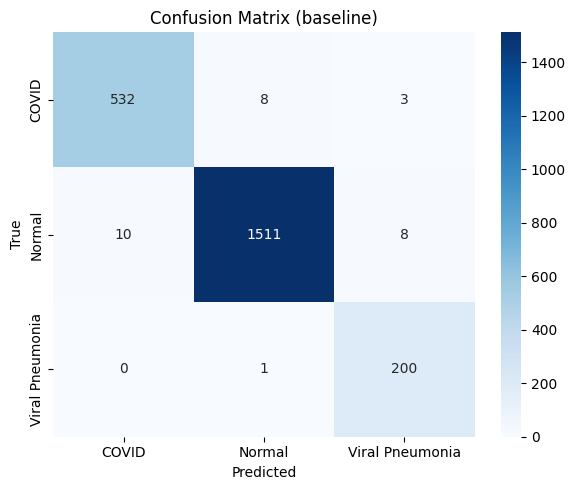

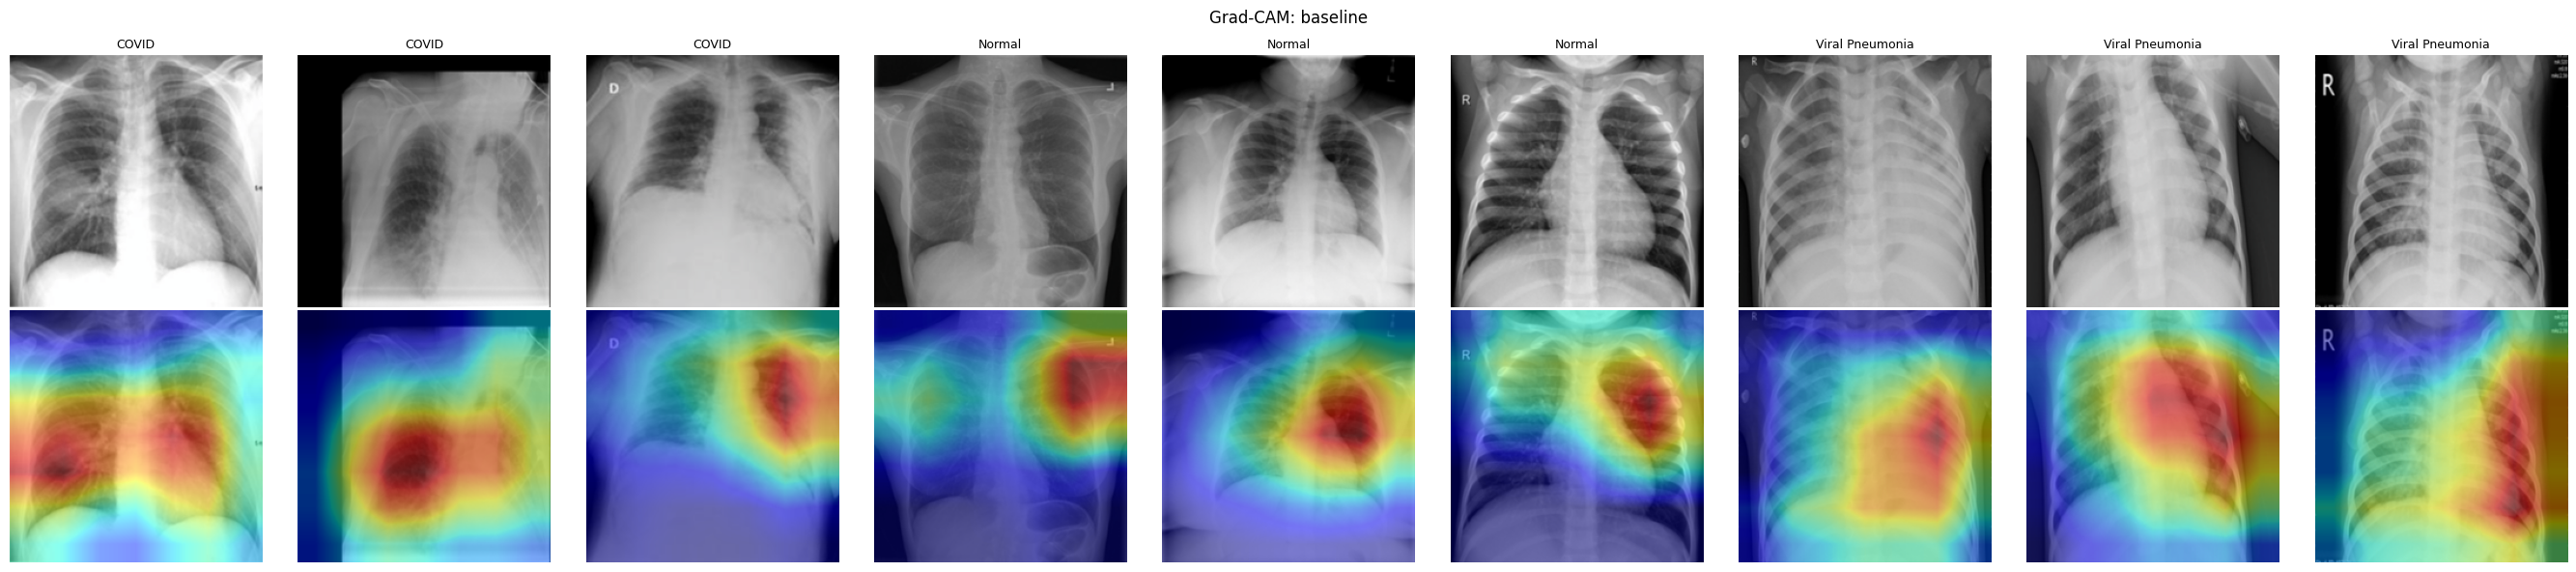

  baseline: acc=0.9868 macro_f1=0.9809 params=11,178,051

Training: se
  epoch  1 | train_loss 0.2224 | val_loss 0.1163 | val_acc 0.9129 | val_f1 0.8959
  epoch  2 | train_loss 0.0938 | val_loss 0.0678 | val_acc 0.9661 | val_f1 0.9593
  epoch  3 | train_loss 0.0701 | val_loss 0.1468 | val_acc 0.9397 | val_f1 0.9340
  epoch  4 | train_loss 0.0641 | val_loss 0.0412 | val_acc 0.9855 | val_f1 0.9783
  epoch  5 | train_loss 0.0448 | val_loss 0.0374 | val_acc 0.9877 | val_f1 0.9790
  epoch  6 | train_loss 0.0449 | val_loss 0.1315 | val_acc 0.9674 | val_f1 0.9576
  epoch  7 | train_loss 0.0437 | val_loss 0.0392 | val_acc 0.9868 | val_f1 0.9812
  epoch  8 | train_loss 0.0340 | val_loss 0.0760 | val_acc 0.9754 | val_f1 0.9686
  epoch  9 | train_loss 0.0352 | val_loss 0.0598 | val_acc 0.9877 | val_f1 0.9827
  epoch 10 | train_loss 0.0257 | val_loss 0.0703 | val_acc 0.9886 | val_f1 0.9830
  early stopping at epoch 10 (best epoch 5)
                 precision    recall  f1-score   support

       

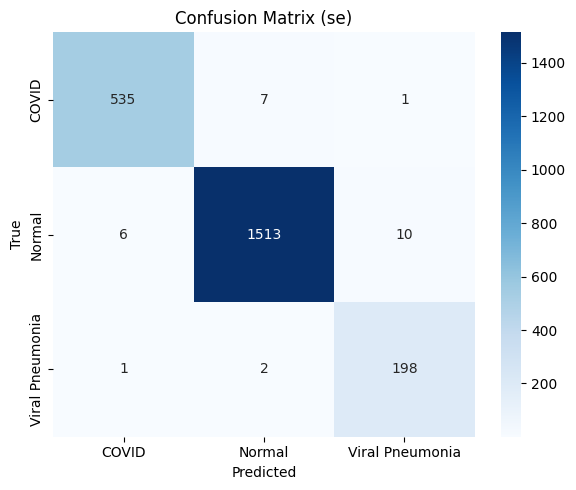

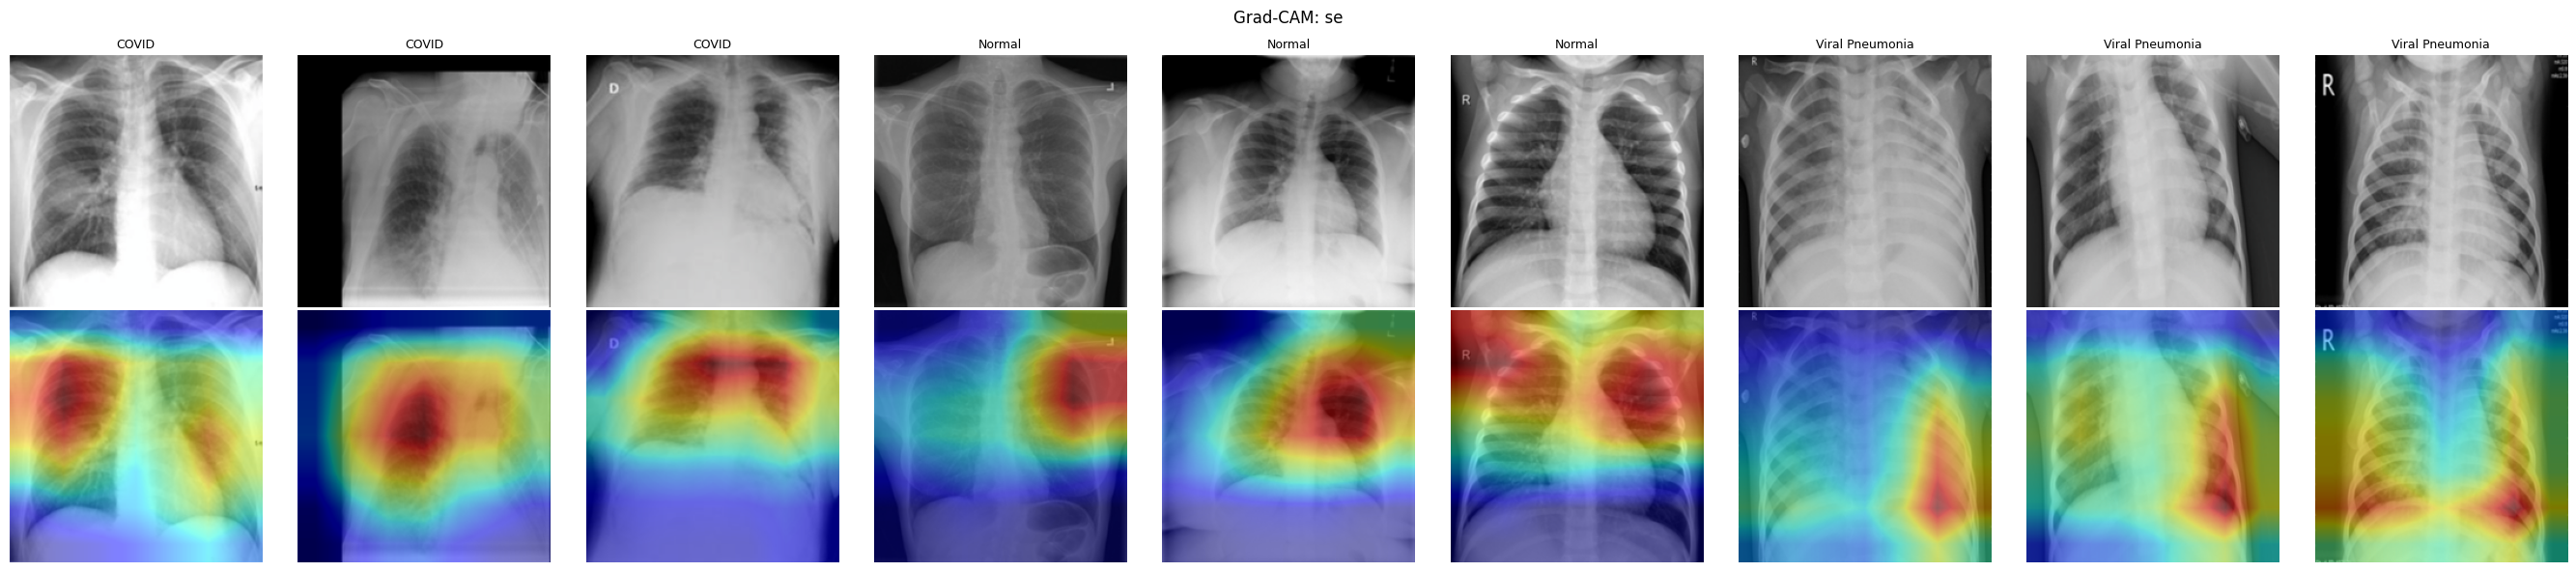

  se: acc=0.9881 macro_f1=0.9813 params=11,222,591

Training: spatial
  epoch  1 | train_loss 0.2161 | val_loss 0.0883 | val_acc 0.9723 | val_f1 0.9678
  epoch  2 | train_loss 0.0943 | val_loss 0.0624 | val_acc 0.9692 | val_f1 0.9529
  epoch  3 | train_loss 0.0629 | val_loss 0.0561 | val_acc 0.9710 | val_f1 0.9544
  epoch  4 | train_loss 0.0593 | val_loss 0.0354 | val_acc 0.9842 | val_f1 0.9788
  epoch  5 | train_loss 0.0519 | val_loss 0.0361 | val_acc 0.9894 | val_f1 0.9840
  epoch  6 | train_loss 0.0462 | val_loss 0.0492 | val_acc 0.9908 | val_f1 0.9857
  epoch  7 | train_loss 0.0416 | val_loss 0.0300 | val_acc 0.9877 | val_f1 0.9852
  epoch  8 | train_loss 0.0285 | val_loss 0.0500 | val_acc 0.9859 | val_f1 0.9818
  epoch  9 | train_loss 0.0357 | val_loss 0.0404 | val_acc 0.9881 | val_f1 0.9846
  epoch 10 | train_loss 0.0335 | val_loss 0.0399 | val_acc 0.9842 | val_f1 0.9786
  epoch 11 | train_loss 0.0221 | val_loss 0.0391 | val_acc 0.9886 | val_f1 0.9851
  epoch 12 | train_loss 0.02

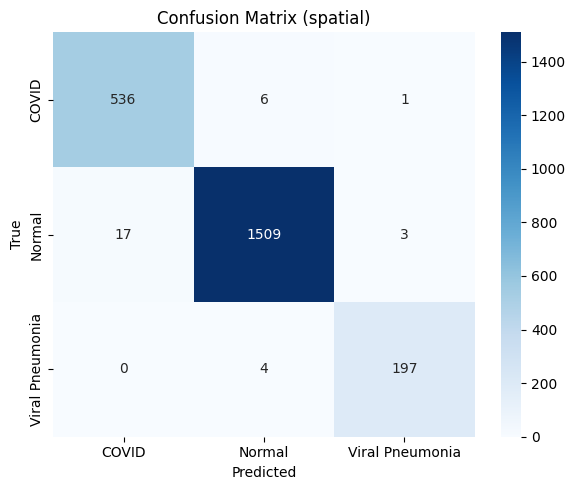

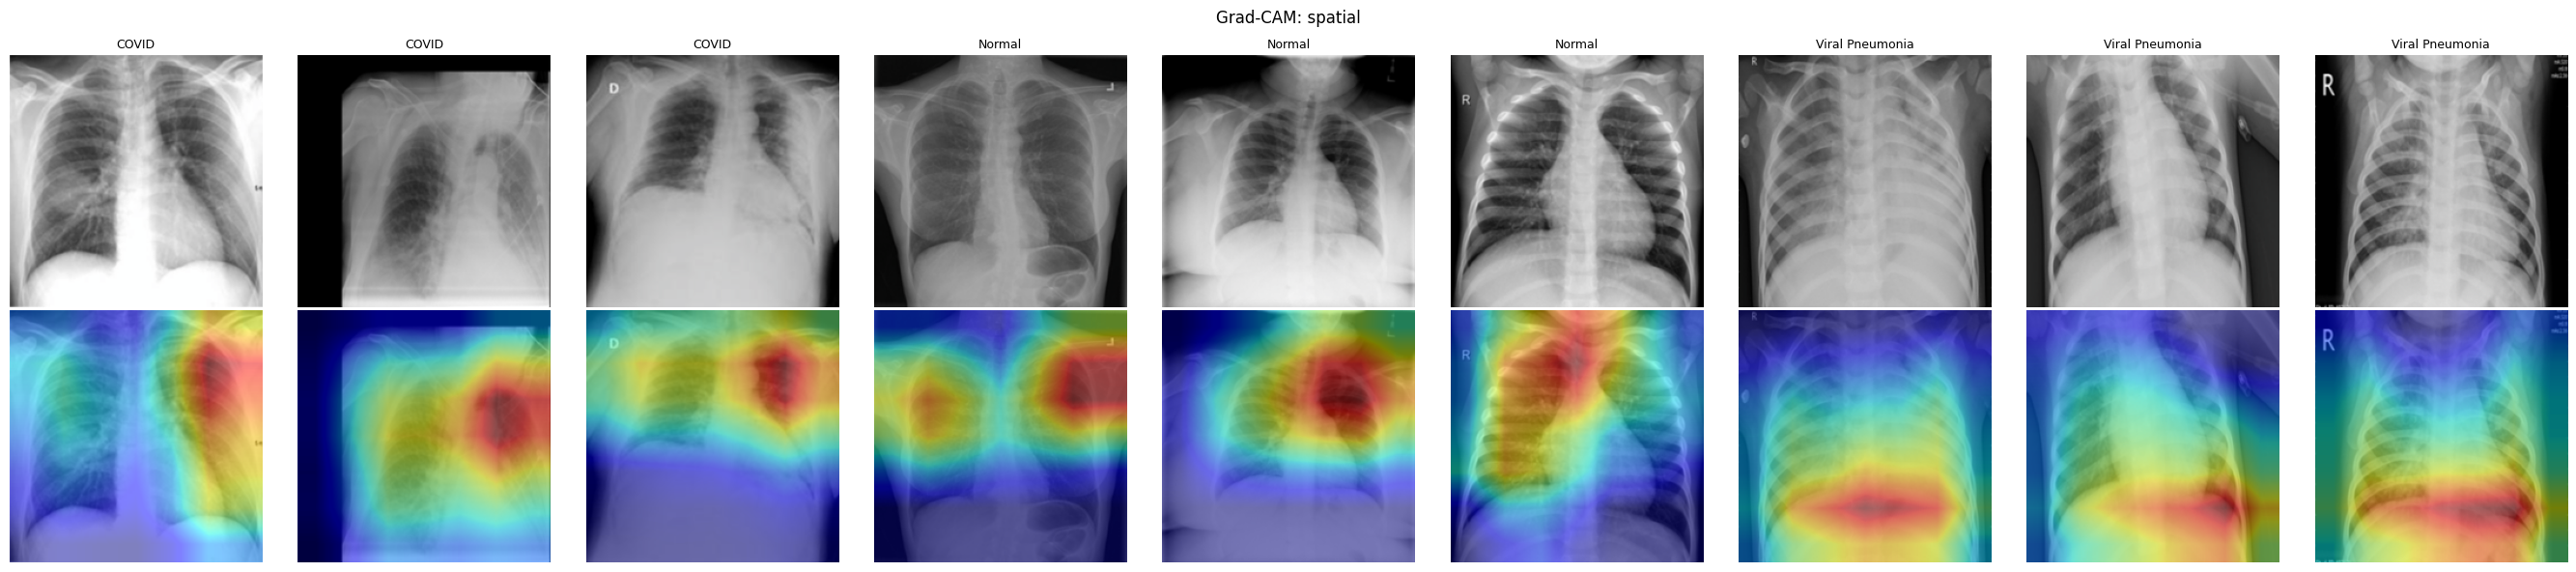

  spatial: acc=0.9864 macro_f1=0.9828 params=11,178,443

Training: eca
  epoch  1 | train_loss 0.2244 | val_loss 0.1243 | val_acc 0.9292 | val_f1 0.8972
  epoch  2 | train_loss 0.0968 | val_loss 0.1459 | val_acc 0.8905 | val_f1 0.8653
  epoch  3 | train_loss 0.0796 | val_loss 0.0712 | val_acc 0.9842 | val_f1 0.9786
  epoch  4 | train_loss 0.0610 | val_loss 0.0661 | val_acc 0.9630 | val_f1 0.9579
  epoch  5 | train_loss 0.0544 | val_loss 0.0490 | val_acc 0.9824 | val_f1 0.9749
  epoch  6 | train_loss 0.0518 | val_loss 0.0680 | val_acc 0.9868 | val_f1 0.9804
  epoch  7 | train_loss 0.0404 | val_loss 0.0418 | val_acc 0.9899 | val_f1 0.9861
  epoch  8 | train_loss 0.0322 | val_loss 0.0363 | val_acc 0.9806 | val_f1 0.9712
  epoch  9 | train_loss 0.0424 | val_loss 0.0292 | val_acc 0.9886 | val_f1 0.9846
  epoch 10 | train_loss 0.0220 | val_loss 0.0417 | val_acc 0.9921 | val_f1 0.9876
  epoch 11 | train_loss 0.0276 | val_loss 0.0274 | val_acc 0.9916 | val_f1 0.9868
  epoch 12 | train_loss 0.0

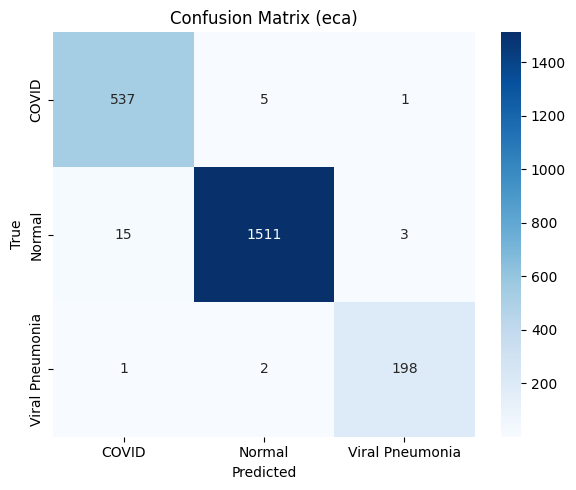

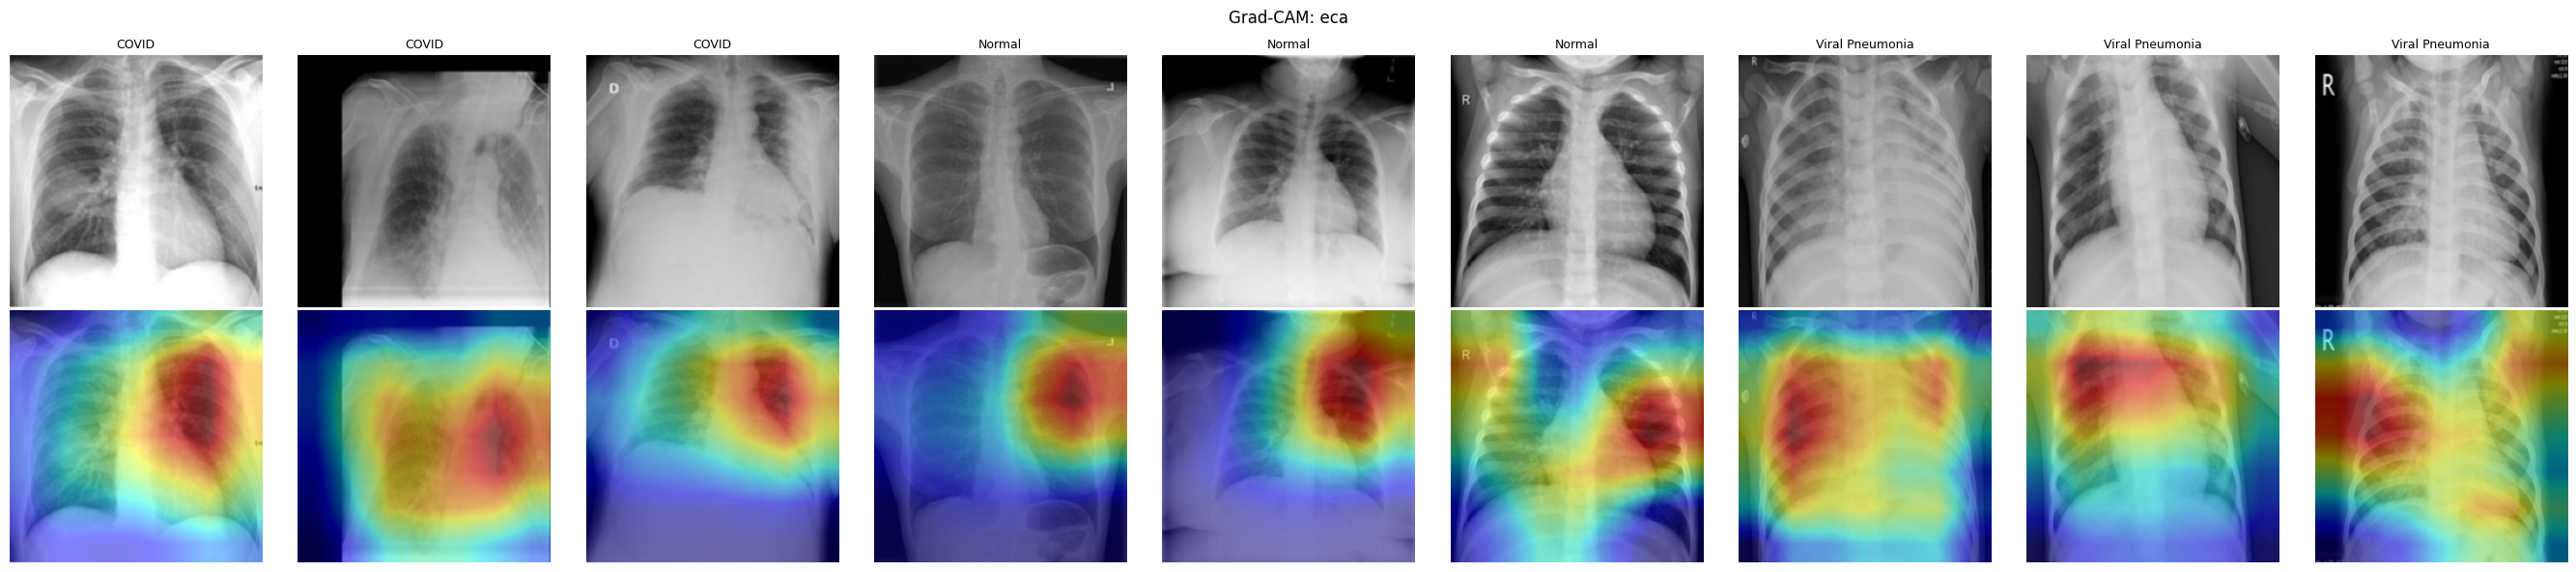

  eca: acc=0.9881 macro_f1=0.9848 params=11,178,069


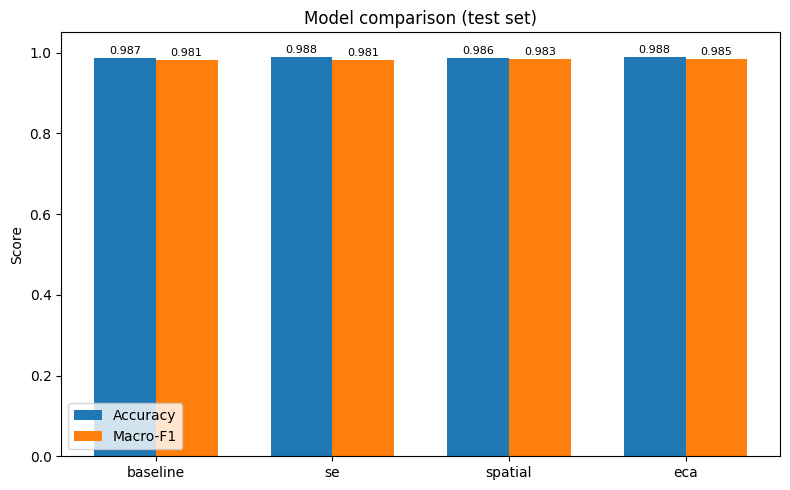

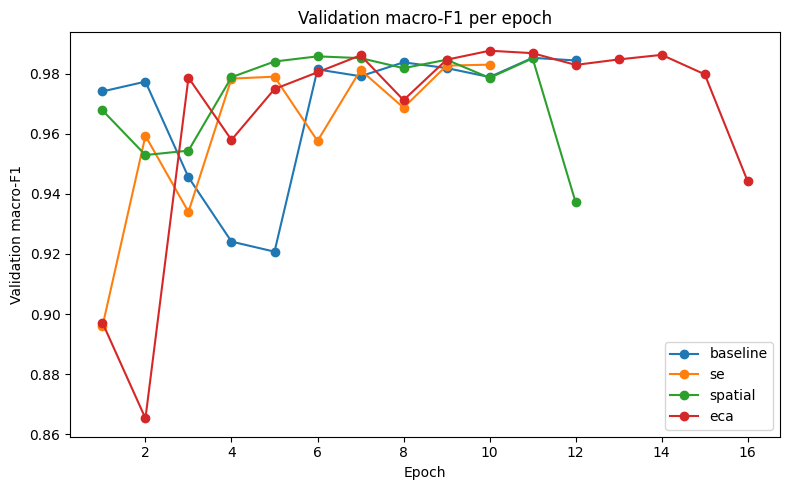

In [ ]:
summary_rows, histories = [], {}
for variant in VARIANTS:
    model, train_info, hist = train_model(variant, train_loader, val_loader, class_weights)
    histories[variant] = hist
    metrics_row = evaluate(model, test_loader, variant)
    metrics_row.update(train_info)
    summary_rows.append(metrics_row)
    gradcam_panel(model, variant, test_df)
    print(f"  {variant}: acc={metrics_row['test_accuracy']} "
          f"macro_f1={metrics_row['macro_f1']} params={train_info['num_params']:,}")

summary = pd.DataFrame(summary_rows)
cols = ["variant", "test_accuracy", "macro_precision", "macro_recall", "macro_f1",
        *[f"f1_{c}" for c in CLASS_NAMES], "num_params", "best_epoch", "train_time_sec"]
summary = summary[cols]
summary.to_csv(DIRS["metrics"] / "metrics_summary.csv", index=False)
comparison_plots(summary, histories)


In [ ]:
print("=" * 60)
print("FINAL SUMMARY (test set)")
print("=" * 60)
print(summary.to_string(index=False))
best = summary.loc[summary["macro_f1"].idxmax(), "variant"]
print(f"\nBest model by macro-F1: {best}")
print(f"\nAll artifacts saved under: {OUTPUT_DIR.resolve()}")
print("  metrics/metrics_summary.csv, metrics/*_classification_report.txt")
print("  figures/*_confusion_matrix.png, *_gradcam.png, comparison_accuracy_f1.png,")
print("          combined_learning_curves.png")
print("  logs/*_history.csv, checkpoints/*_best.pt, split/{train,val,test}.csv")

summary


FINAL SUMMARY (test set)
 variant  test_accuracy  macro_precision  macro_recall  macro_f1  f1_COVID  f1_Normal  f1_Viral Pneumonia  num_params  best_epoch  train_time_sec
baseline         0.9868           0.9745        0.9877    0.9809    0.9806     0.9911              0.9709    11178051           7           519.0
      se         0.9881           0.9762        0.9866    0.9813    0.9862     0.9918              0.9659    11222591           5           380.2
 spatial         0.9864           0.9809        0.9847    0.9828    0.9781     0.9902              0.9801    11178443           7           484.5
     eca         0.9881           0.9822        0.9874    0.9848    0.9799     0.9918              0.9826    11178069          11           621.5

Best model by macro-F1: eca

All artifacts saved under: /content/drive/MyDrive/cxr_outputs
  metrics/metrics_summary.csv, metrics/*_classification_report.txt
  figures/*_confusion_matrix.png, *_gradcam.png, comparison_accuracy_f1.png,
         

,variant,test_accuracy,macro_precision,macro_recall,macro_f1,f1_COVID,f1_Normal,f1_Viral Pneumonia,num_params,best_epoch,train_time_sec
0,baseline,0.9868,0.9745,0.9877,0.9809,0.9806,0.9911,0.9709,11178051,7,519.0
1,se,0.9881,0.9762,0.9866,0.9813,0.9862,0.9918,0.9659,11222591,5,380.2
2,spatial,0.9864,0.9809,0.9847,0.9828,0.9781,0.9902,0.9801,11178443,7,484.5
3,eca,0.9881,0.9822,0.9874,0.9848,0.9799,0.9918,0.9826,11178069,11,621.5
